## 1. Imports e Carregamento dos Splits


In [ ]:
import pandas as pd
import joblib
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

    
print("Carregando splits físicos...")
df_train = pd.read_csv('../../data/splits/train.csv')
df_val   = pd.read_csv('../../data/splits/val.csv')
df_test  = pd.read_csv('../../data/splits/test.csv')

X_train, y_train_raw = df_train.drop('classe', axis=1), df_train['classe']
X_val,   y_val_raw   = df_val.drop('classe', axis=1),   df_val['classe']
X_test,  y_test_raw  = df_test.drop('classe', axis=1),  df_test['classe']

le = LabelEncoder().fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f"Treino:    {len(X_train):4d} amostras")
print(f"Validação: {len(X_val):4d} amostras")
print(f"Teste:     {len(X_test):4d} amostras")
print(f"\nClasses: {list(le.classes_)}")


Carregando splits físicos...
Treino:    1119 amostras
Validação:  241 amostras
Teste:      240 amostras

Classes: ['Empate', 'O venceu', 'Tem jogo', 'X venceu']


## 2. Treinamento do MLP


In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from scipy.stats import loguniform, randint

# 1. Pipeline
pipeline = Pipeline([
    # ('smote', SMOTE(random_state=42)), # Descomente se precisar balancear os dados
    ('mlp', MLPClassifier(random_state=42))
])

# 2. Grid de parâmetros expandido
param_dist = {
    'mlp__hidden_layer_sizes': [
        (32,), (64,), (128,), 
        (64, 32), (128, 64), 
        (128, 64, 32), (256, 128, 64)
    ],
    'mlp__activation':         ['relu', 'tanh', 'logistic'], # Adicionada a função logística (sigmoid)
    'mlp__solver':             ['adam', 'sgd'],             # Testar diferentes otimizadores
    'mlp__alpha':              [1e-5, 1e-4, 1e-3, 1e-2, 1e-1], # Faixa mais ampla de regularização L2
    'mlp__learning_rate_init': [1e-4, 1e-3, 1e-2, 1e-1],       # Mais opções para a taxa de aprendizado
    'mlp__learning_rate':      ['constant', 'adaptive'],     # Como o learning rate se comporta
    'mlp__max_iter':           [1000, 1500, 2000, 2500],     # Variação do número máximo de iterações
    'mlp__batch_size':         ['auto', 32, 64, 128]         # Tamanho dos lotes (mini-batch)
}

# 3. RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,                     
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Melhores parâmetros:", random_search.best_params_)
print("Melhor acurácia:", random_search.best_score_)

Melhores parâmetros: {'mlp__solver': 'sgd', 'mlp__max_iter': 1000, 'mlp__learning_rate_init': 0.1, 'mlp__learning_rate': 'adaptive', 'mlp__hidden_layer_sizes': (256, 128, 64), 'mlp__batch_size': 32, 'mlp__alpha': 0.01, 'mlp__activation': 'relu'}
Melhor acurácia: 0.9678291159513133


In [217]:
mlp = random_search.best_estimator_
print(f"Treinando modelo final...{mlp}")
mlp.fit(X_train, y_train)
print("Treinamento concluído.")

Treinando modelo final...Pipeline(steps=[('mlp',
                 MLPClassifier(alpha=0.01, batch_size=32,
                               hidden_layer_sizes=(256, 128, 64),
                               learning_rate='adaptive', learning_rate_init=0.1,
                               max_iter=1000, random_state=42, solver='sgd'))])
Treinamento concluído.


## 3. Avaliação no Conjunto de Validação


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

      Empate       0.67      0.40      0.50         5
    O venceu       0.96      1.00      0.98        48
    Tem jogo       0.97      0.95      0.96        94
    X venceu       0.98      1.00      0.99        94

    accuracy                           0.97       241
   macro avg       0.89      0.84      0.86       241
weighted avg       0.96      0.97      0.96       241



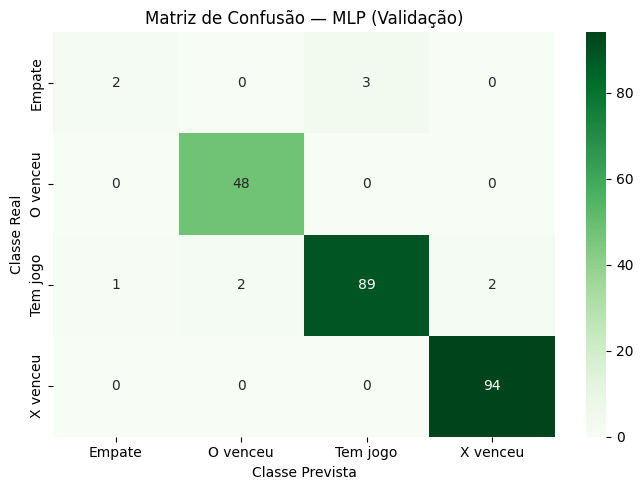

In [218]:
y_val_pred = mlp.predict(X_val)

print("=== VALIDAÇÃO ===")
print(classification_report(
    le.inverse_transform(y_val),
    le.inverse_transform(y_val_pred),
    zero_division=0,
))

plt.figure(figsize=(7, 5))
cm_val = confusion_matrix(le.inverse_transform(y_val), le.inverse_transform(y_val_pred), labels=le.classes_)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — MLP (Validação)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 4. Avaliação Final no Conjunto de Teste


=== TESTE ===
              precision    recall  f1-score   support

      Empate       1.00      0.40      0.57         5
    O venceu       0.96      1.00      0.98        47
    Tem jogo       0.97      0.98      0.97        94
    X venceu       1.00      1.00      1.00        94

    accuracy                           0.98       240
   macro avg       0.98      0.84      0.88       240
weighted avg       0.98      0.98      0.98       240



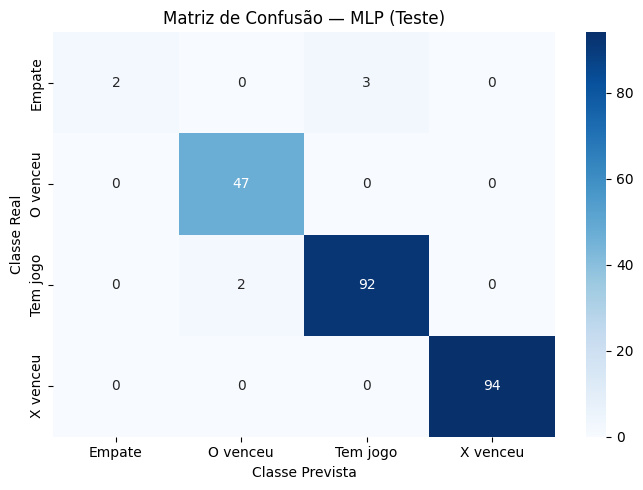

In [219]:
y_test_pred = mlp.predict(X_test)

print("=== TESTE ===")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_test_pred),
    zero_division=0,
))

plt.figure(figsize=(7, 5))
cm_test = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_test_pred), labels=le.classes_)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — MLP (Teste)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 5. Persistência do Modelo


In [220]:
import os
os.makedirs('../../models/MLP', exist_ok=True)
joblib.dump(mlp, '../../models/MLP/mlp_model.pkl')
joblib.dump(le,  '../../models/MLP/mlp_label_encoder.pkl')
print("Modelo e Encoder salvos com sucesso!")


Modelo e Encoder salvos com sucesso!
